In [5]:
import numpy as np
import pandas as pd
import random
import json

# ==========================================
# 1. 定义单碱基数字化规则与保存词表
# ==========================================
# 这是你制定的核心规则，我们将严格执行
char_vocab = {
    '<PAD>': 0,  # 用于填充短序列
    'A': 1,
    'T': 2,
    'C': 3,
    'G': 4,
    'N': 5      # 用于处理未知或非 ATCG 碱基
}

# 将词表固化保存为 JSON，防止未来推理时顺序错乱
with open("single_base_vocab.json", "w", encoding="utf-8") as f:
    json.dump(char_vocab, f, indent=4)
print(f"✅ 单碱基词表已固化保存至: single_base_vocab.json")


# ==========================================
# 2. 定义原始 ATCG 字符串合成函数
# ==========================================
def generate_raw_atcg_sequences(num_samples=5000, seq_length=100):
    """
    合成原始 DNA 字符串。
    正样本 (Label=1): 在位置 60-70 之间植入 TATA box ('TATAAAA') 特征。
    负样本 (Label=0): 完全随机。
    """
    print(f"\n正在合成 {num_samples} 条长度为 {seq_length}bp 的原始 DNA 字符串...")
    
    bases = ['A', 'T', 'C', 'G']
    half_samples = num_samples // 2
    
    raw_sequences = []
    labels = []
    
    # --- 生成负样本 (Label=0) ---
    for _ in range(half_samples):
        # np.random.choice 速度更快
        seq = ''.join(np.random.choice(bases, seq_length))
        raw_sequences.append(seq)
        labels.append(0)
        
    # --- 生成正样本 (Label=1) ---
    tata_box = "TATAAAA"
    for _ in range(half_samples):
        # 先生成随机背景
        seq_list = list(np.random.choice(bases, seq_length))
        # 模拟 TATA box 在起始位点上游的位置波动 (植入在 index 60-70 之间)
        insert_pos = random.randint(60, 70) 
        # 植入特征
        seq_list[insert_pos : insert_pos + len(tata_box)] = list(tata_box)
        
        # 进阶：30% 概率在更上游植入 CAAT box ('CCAAT') 增加特征多样性
        if random.random() < 0.3:
            caat_box = "CCAAT"
            caat_pos = random.randint(20, 40)
            seq_list[caat_pos : caat_pos + len(caat_box)] = list(caat_box)
            
        seq = ''.join(seq_list)
        raw_sequences.append(seq)
        labels.append(1)
        
    return raw_sequences, labels


# ==========================================
# 3. 执行合成 & 严格按照单碱基规则数字化映射
# ==========================================
# 3.1 获取原始字符串数据
raw_seqs, raw_labels = generate_raw_atcg_sequences(num_samples=5000, seq_length=100)

print("正在执行单碱基数字化映射与对齐 (Padding/Truncating)...")
# 我们设定的统一长度
target_len = 100 

X_indices = []
for seq in raw_seqs:
    # --- 灵魂步骤：单碱基映射 (A->1, T->2...) ---
    # 直接遍历字符串，查 char_vocab 字典，找不到的给 5 ('N')
    indices = [char_vocab.get(base, 5) for base in seq]
    
    # --- 对齐步骤：Padding (填充) 或 Truncating (截断) ---
    current_len = len(indices)
    if current_len < target_len:
        # 长度不够：在末尾用 0 (<PAD>) 补齐
        padded_indices = indices + [0] * (target_len - current_len)
    else:
        # 长度超标（虽然合成数据不会，但真实数据会）：直接截断
        padded_indices = indices[:target_len]
        
    X_indices.append(padded_indices)


# ==========================================
# 4. 转换为最终建模所需的 Numpy 矩阵并打乱
# ==========================================
# 转换为标准矩形矩阵
X = np.array(X_indices) # 形状: (5000, 100)
y = np.array(raw_labels)   # 形状: (5000,)

# 核心步骤：随机打乱样本顺序 (Shuffling)，防止模型产生批次偏差
# 创建一个随机索引排列
indices_shuffled = np.arange(X.shape[0])
np.random.seed(42) # 固定随机种子，保证结果可复现
np.random.shuffle(indices_shuffled)

# 应用打乱后的索引
X_final = X[indices_shuffled]
y_final = y[indices_shuffled]

print("\n" + "="*40)
print("✅ 用于建模的单碱基数据集已准备就绪！")
print(f"特征矩阵 X 形状 (Samples, SeqLen): {X_final.shape}")
print(f"特征矩阵 X 数据类型: {X_final.dtype}") # 应该是 int64
print(f"标签向量 y 形状: {y_final.shape}")
print(f"随机打乱校验 (前5个 X 的前10个base索引):\n{X_final[:5, :10]}")
print("="*40)

# ==========================================
# 5. 保存数据为 Numpy 专用文件 (.npy)
# ==========================================
# 相比 CSV，.npy 文件保存多维矩阵速度极快且不丢失数据类型信息
np.save("X_single_base.npy", X_final)
np.save("y_single_base.npy", y_final)
print(f"\n数据集已保存为: X_single_base.npy 和 y_single_base.npy")
print("你可以在 PyTorch Dataset 中直接使用 np.load() 读取它们。")

✅ 单碱基词表已固化保存至: single_base_vocab.json

正在合成 5000 条长度为 100bp 的原始 DNA 字符串...
正在执行单碱基数字化映射与对齐 (Padding/Truncating)...

✅ 用于建模的单碱基数据集已准备就绪！
特征矩阵 X 形状 (Samples, SeqLen): (5000, 100)
特征矩阵 X 数据类型: int64
标签向量 y 形状: (5000,)
随机打乱校验 (前5个 X 的前10个base索引):
[[2 3 3 1 2 4 3 2 1 3]
 [1 2 1 2 3 1 2 4 3 1]
 [3 4 4 4 3 3 3 4 3 3]
 [3 3 3 1 1 4 2 4 4 1]
 [1 3 2 2 1 4 3 4 4 2]]

数据集已保存为: X_single_base.npy 和 y_single_base.npy
你可以在 PyTorch Dataset 中直接使用 np.load() 读取它们。


In [7]:
print(y_final[:5])

[0 1 1 0 0]


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
import numpy as np
import math

# ==========================================
# 1. 加载数据并进行三划分 (Train / Val / Test)
# ==========================================
print("1. 正在加载单碱基序列数据...")
X = np.load("X_single_base.npy")
y = np.load("y_single_base.npy")

# 第一次划分：70% 训练，30% 临时 (分层抽样保证正负样本均衡)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 第二次划分：15% 验证，15% 测试
X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

# 转为 PyTorch 张量
def to_tensor(X, y):
    return torch.tensor(X, dtype=torch.long), torch.tensor(y, dtype=torch.long)

X_train_t, y_train_t = to_tensor(X_train, y_train)
X_valid_t, y_valid_t = to_tensor(X_valid, y_valid)
X_test_t,  y_test_t  = to_tensor(X_test, y_test)

# 构建 DataLoader
batch_size = 64
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(TensorDataset(X_valid_t, y_valid_t), batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(TensorDataset(X_test_t,  y_test_t),  batch_size=batch_size, shuffle=False)

print(f"数据加载完成！训练集: {len(y_train)}, 验证集: {len(y_valid)}, 测试集: {len(y_test)}")

# ==========================================
# 3. 定义单碱基 Transformer 模型
# ==========================================
class CNN_DNA_Transformer(nn.Module):
    # 新增了一个参数 max_seq_len=100，告诉字典我们需要准备多少个“座位号”
    def __init__(self, vocab_size=6, d_model=64, nhead=4, num_layers=2, num_classes=2, max_seq_len=100):
        super(CNN_DNA_Transformer, self).__init__()
        
        # 1. 碱基词嵌入
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=0)
        
        # 2. 局部 Motif 扫描仪 (CNN)
        self.conv1d = nn.Conv1d(
            in_channels=d_model, 
            out_channels=d_model, 
            kernel_size=7, 
            padding=3
        )
        self.relu = nn.ReLU()
        
        # ==========================================
        # 🌟 核心替换：一行代码搞定位置编码！
        # 建立一个大小为 100 的字典，每个位置对应一个 64 维的可学习向量
        # ==========================================
        self.pos_embedding = nn.Embedding(max_seq_len, d_model)
        
        # 3. Transformer 编码器
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, 
            nhead=nhead, 
            dim_feedforward=256, 
            dropout=0.2, 
            batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        # 4. 分类头
        self.fc = nn.Linear(d_model, num_classes)

    def forward(self, x):
        # 获取当前批次的序列长度 (理论上一直是 100)
        seq_len = x.size(1)
        
        # 1. 查表获取碱基特征
        x = self.embedding(x) * math.sqrt(self.embedding.embedding_dim) 
        
        # 2. CNN 提取局部 Motif
        x = x.permute(0, 2, 1) 
        x = self.relu(self.conv1d(x))
        x = x.permute(0, 2, 1) 
        
        # ==========================================
        # 🌟 核心替换：动态生成座位号，查表相加！
        # ==========================================
        # 生成 [0, 1, 2, ..., seq_len-1] 的座位号，并放到和 x 一样的设备上 (CPU/GPU)
        positions = torch.arange(0, seq_len, dtype=torch.long, device=x.device).unsqueeze(0)
        # 用座位号去 pos_embedding 字典里查出特征，直接加给 x
        x = x + self.pos_embedding(positions)
        
        # 3. Transformer 全局处理
        x = self.transformer_encoder(x)
        x = x.mean(dim=1)
        x = self.fc(x)
        return x


# ==========================================
# 4. 初始化模型、损失函数与优化器
# ==========================================
# 实例化并丢入显卡/CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNN_DNA_Transformer(d_model=64, nhead=4, num_layers=2).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5) # 加入轻微的 L2 正则化防过拟合

# ==========================================
# 5. 训练与验证循环
# ==========================================
num_epochs = 10
best_val_acc = 0.0

print(f"\n🚀 开始在 {device} 上训练单碱基 Transformer...")

for epoch in range(num_epochs):
    # --- 训练模式 ---
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    
    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        
        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += batch_y.size(0)
        correct += (predicted == batch_y).sum().item()
        
    train_acc = 100 * correct / total
    
    # --- 验证模式 ---
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    
    with torch.no_grad():
        for batch_x, batch_y in valid_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            val_total += batch_y.size(0)
            val_correct += (predicted == batch_y).sum().item()
            
    val_acc = 100 * val_correct / val_total
    
    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {running_loss/len(train_loader):.4f}, Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss/len(valid_loader):.4f}, Val Acc: {val_acc:.2f}%")
    
    # 保存泛化能力最好的模型
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_single_base_transformer.pth')

# ==========================================
# 6. 测试集终极盲测
# ==========================================
print("\n🔥 正在加载最佳模型进行测试集盲测...")
model.load_state_dict(torch.load('best_single_base_transformer.pth'))
model.eval()
test_correct, test_total = 0, 0

with torch.no_grad():
    for batch_x, batch_y in test_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        outputs = model(batch_x)
        _, predicted = torch.max(outputs, 1)
        test_total += batch_y.size(0)
        test_correct += (predicted == batch_y).sum().item()

print(f"✅ 单碱基 Transformer 测试集最终准确率: {100 * test_correct / test_total:.2f}%")

1. 正在加载单碱基序列数据...
数据加载完成！训练集: 3500, 验证集: 750, 测试集: 750

🚀 开始在 cpu 上训练单碱基 Transformer...
Epoch [1/10] Train Loss: 0.3622, Train Acc: 81.31% | Val Loss: 0.0630, Val Acc: 98.53%
Epoch [2/10] Train Loss: 0.0340, Train Acc: 99.20% | Val Loss: 0.0256, Val Acc: 99.33%
Epoch [3/10] Train Loss: 0.0220, Train Acc: 99.49% | Val Loss: 0.0279, Val Acc: 99.60%
Epoch [4/10] Train Loss: 0.0190, Train Acc: 99.49% | Val Loss: 0.0390, Val Acc: 99.47%
Epoch [5/10] Train Loss: 0.0215, Train Acc: 99.49% | Val Loss: 0.0288, Val Acc: 99.60%
Epoch [6/10] Train Loss: 0.0112, Train Acc: 99.80% | Val Loss: 0.0282, Val Acc: 99.60%
Epoch [7/10] Train Loss: 0.0090, Train Acc: 99.86% | Val Loss: 0.0344, Val Acc: 99.20%
Epoch [8/10] Train Loss: 0.0117, Train Acc: 99.83% | Val Loss: 0.0290, Val Acc: 99.60%
Epoch [9/10] Train Loss: 0.0102, Train Acc: 99.80% | Val Loss: 0.0331, Val Acc: 99.60%
Epoch [10/10] Train Loss: 0.0090, Train Acc: 99.83% | Val Loss: 0.0387, Val Acc: 99.47%

🔥 正在加载最佳模型进行测试集盲测...


/var/folders/0g/1st6ryj54n1bshvyq3yt1pzm0000gn/T/ipykernel_63104/1087029299.py:176: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('best_sing

✅ 单碱基 Transformer 测试集最终准确率: 99.73%


🔥 正在加载最佳模型进行测试集终极盲测...

✅ 消除警告后的完美运行！测试集最终准确率: 99.73%

-------------------------------------------------------
详细分类报告 (Classification Report):
-------------------------------------------------------
                    precision    recall  f1-score   support

非启动子 (Negative: 0)       1.00      0.99      1.00       375
 启动子 (Positive: 1)       0.99      1.00      1.00       375

          accuracy                           1.00       750
         macro avg       1.00      1.00      1.00       750
      weighted avg       1.00      1.00      1.00       750



/Users/zengjian/miniforge3/envs/deepchem/lib/python3.9/site-packages/seaborn/utils.py:61: UserWarning: Glyph 38750 (\N{CJK UNIFIED IDEOGRAPH-975E}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/Users/zengjian/miniforge3/envs/deepchem/lib/python3.9/site-packages/seaborn/utils.py:61: UserWarning: Glyph 21551 (\N{CJK UNIFIED IDEOGRAPH-542F}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/Users/zengjian/miniforge3/envs/deepchem/lib/python3.9/site-packages/seaborn/utils.py:61: UserWarning: Glyph 21160 (\N{CJK UNIFIED IDEOGRAPH-52A8}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/Users/zengjian/miniforge3/envs/deepchem/lib/python3.9/site-packages/seaborn/utils.py:61: UserWarning: Glyph 23376 (\N{CJK UNIFIED IDEOGRAPH-5B50}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/Users/zengjian/miniforge3/envs/deepchem/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 38750 (\N{CJK UNIFIED IDEOGRAPH-975E}) missing from font(s) DejaVu Sans.

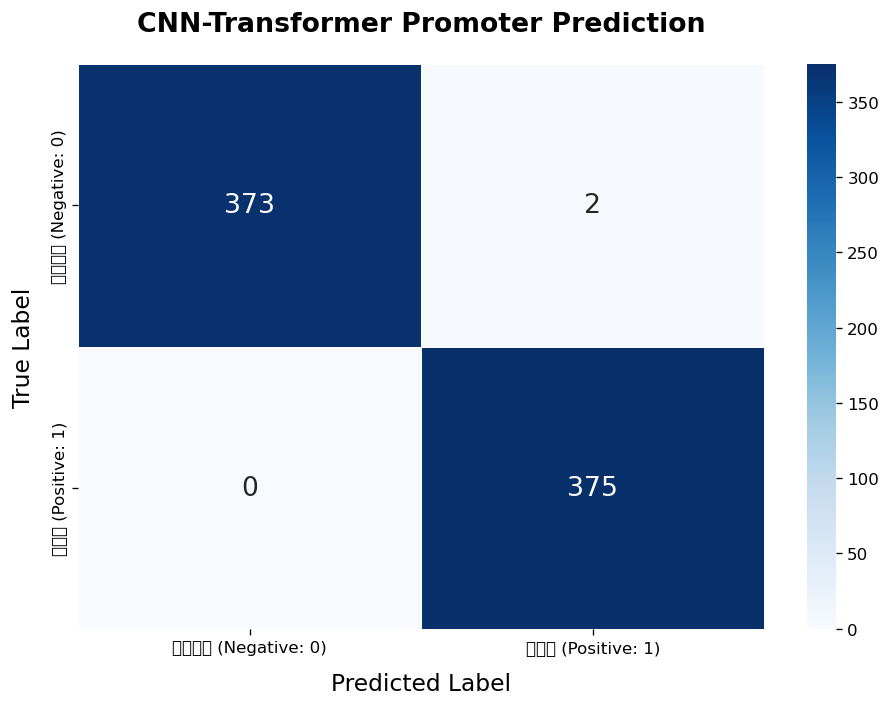

In [14]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# ==========================================
# 1. 安全加载模型 (完美消除红色警告)
# ==========================================
print("🔥 正在加载最佳模型进行测试集终极盲测...")
# 核心修复：加入 weights_only=True
model.load_state_dict(torch.load('best_single_base_transformer.pth', weights_only=True))
model.eval()

# ==========================================
# 2. 在 Test Loader 上进行推理并收集结果
# ==========================================
all_preds = []
all_labels = []

with torch.no_grad():
    for batch_x, batch_y in test_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        outputs = model(batch_x)
        _, predicted = torch.max(outputs, 1)
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(batch_y.cpu().numpy())
        

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# ==========================================
# 3. 打印核心指标与分类报告
# ==========================================
test_acc = 100 * np.sum(all_preds == all_labels) / len(all_labels)
print(f"\n✅ 消除警告后的完美运行！测试集最终准确率: {test_acc:.2f}%\n")

print("-" * 55)
print("详细分类报告 (Classification Report):")
print("-" * 55)
target_names = ["非启动子 (Negative: 0)", "启动子 (Positive: 1)"]
print(classification_report(all_labels, all_preds, target_names=target_names))

# ==========================================
# 4. 绘制终极混淆矩阵图
# ==========================================
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6), dpi=120)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_names, yticklabels=target_names,
            linewidths=.5, annot_kws={"size": 16})

plt.title('CNN-Transformer Promoter Prediction', fontsize=16, pad=20, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=14, labelpad=10)
plt.ylabel('True Label', fontsize=14, labelpad=10)

plt.tight_layout()
plt.show()

🧬 正在从测试集中捕获真实的启动子序列...
🔍 正在反向追踪各个碱基对预测结果的贡献度...
🎨 正在绘制碱基级高分辨率热力图...


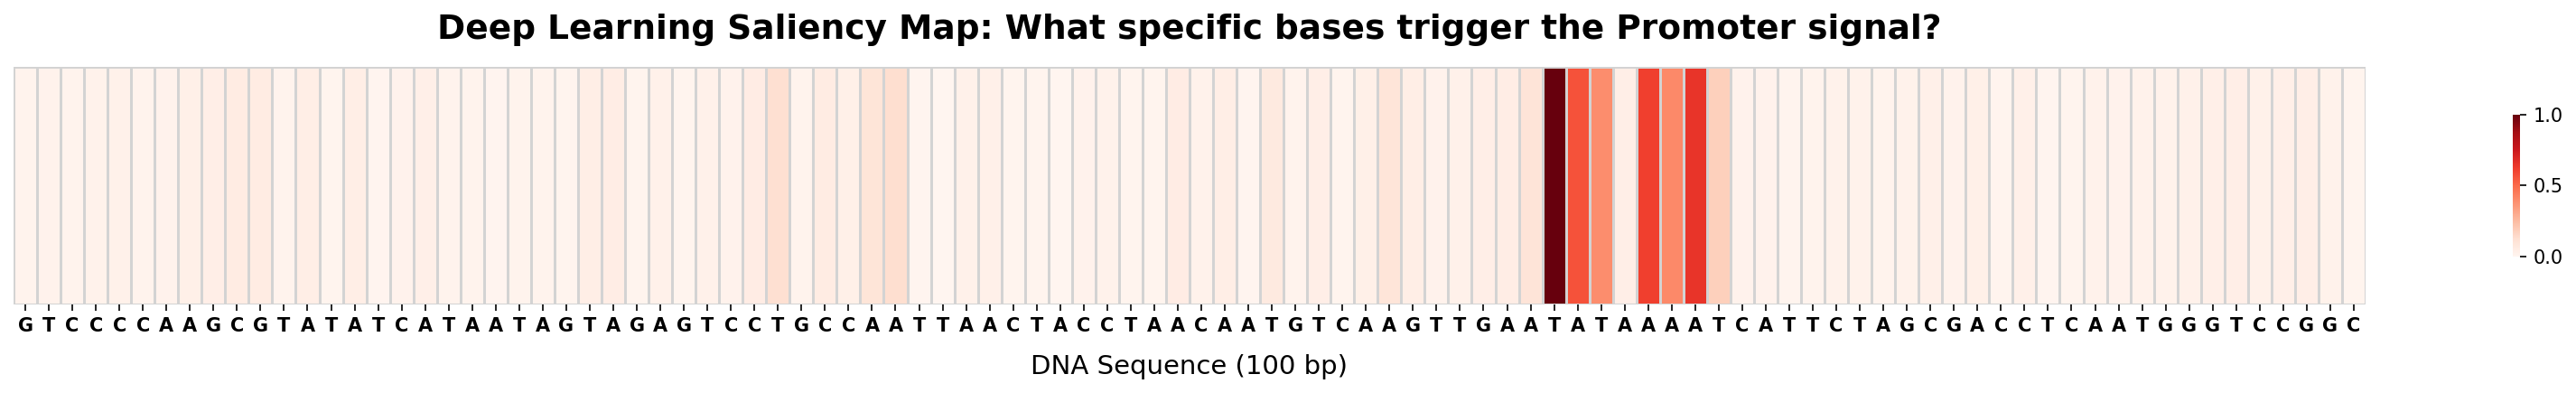

In [15]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. 抓取“试验品”与还原字母
# ==========================================
print("🧬 正在从测试集中捕获真实的启动子序列...")
# 找到所有真实的启动子 (Label=1) 的索引
positive_indices = np.where(y_test == 1)[0]
# 我们就拿第一个启动子开刀
sample_idx = positive_indices[0]  

# 准备好喂给模型的张量
seq_tensor = torch.tensor([X_test[sample_idx]], dtype=torch.long).to(device)

# 准备好我们画图用的 ATCG 字母序列
reverse_vocab = {v: k for k, v in char_vocab.items()}
seq_chars = [reverse_vocab.get(idx, 'N') for idx in X_test[sample_idx]]

# ==========================================
# 2. 深度学习黑魔法：梯度反向追踪
# ==========================================
print("🔍 正在反向追踪各个碱基对预测结果的贡献度...")
model.eval() # 确保关闭 Dropout 等随机因素

# 存放前向特征和反向梯度的容器
embeddings = []
gradients = []

# 定义拦截器 (Hook)
def forward_hook(module, input, output):
    embeddings.append(output)
    # 注册反向钩子，当梯度传回这里时，把它死死抓住
    output.register_hook(lambda grad: gradients.append(grad))
    
# 把拦截器挂在第一层 (Embedding层) 上
hook_handle = model.embedding.register_forward_hook(forward_hook)

# 前向传播 (极其注意：这里绝对不能加 torch.no_grad()，因为我们需要梯度！)
model.zero_grad()
preds = model(seq_tensor)

# 我们只关注模型认定 "它是启动子 (索引为 1)" 的那个维度的得分
target_score = preds[0, 1] 

# 核心：顺藤摸瓜，反向传播求导！
target_score.backward()

# 用完即弃，拆除拦截器
hook_handle.remove()

# ==========================================
# 3. 计算重要性得分 (Grad x Input 算法)
# ==========================================
# 把特征和梯度相乘，然后在 64 维上求和，浓缩成每个碱基的 1 个得分
saliency_map = (embeddings[0] * gradients[0]).sum(dim=-1).squeeze().detach().cpu().numpy()
# 我们只关心影响力的绝对大小
saliency_map = np.abs(saliency_map) 

# 将得分归一化到 0-1 之间，让颜色对比更极致
saliency_map = (saliency_map - saliency_map.min()) / (saliency_map.max() - saliency_map.min())

# ==========================================
# 4. 绘制终极极客风热力图
# ==========================================
print("🎨 正在绘制碱基级高分辨率热力图...")
# 设置一张非常长的高清画板，因为有 100 个字母
plt.figure(figsize=(22, 3), dpi=150)

# 把一维数组转成 1x100 的矩阵，喂给 Seaborn
sns.heatmap(saliency_map.reshape(1, -1), cmap='Reds', cbar_kws={'shrink': 0.6}, 
            xticklabels=seq_chars, yticklabels=False, linewidths=0.5, linecolor='lightgray')

plt.title('Deep Learning Saliency Map: What specific bases trigger the Promoter signal?', 
          fontsize=18, pad=15, fontweight='bold')
plt.xlabel('DNA Sequence (100 bp)', fontsize=14, labelpad=10)

# 调整字体大小，确保 100 个字母都能看清
plt.xticks(rotation=0, fontsize=10, fontweight='bold')
plt.tight_layout()

# 如果想保存这幅杰作，取消下面这行的注释
# plt.savefig('promoter_saliency_map.png', bbox_inches='tight')
plt.show()